## Data Preprocessing — Customer Churn Classification

Pipeline: Drop ID → Handle Missing → Encode Categoricals → Feature Engineering → Split → Scale → Handle Imbalance

### Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler

train_df = pd.read_csv("../data/churn_train.csv")
test_df = pd.read_csv("../data/churn_test.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

Train shape: (440833, 12)
Test shape:  (64374, 12)


### 1. Drop cột không cần thiết

- `CustomerID` là cột định danh, không mang thông tin dự đoán
- Nếu giữ lại, model sẽ "memorize" ID → overfitting

In [2]:
drop_cols = ["CustomerID"]

train_df = train_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

print(f"Train columns: {train_df.columns.tolist()}")
print(f"Train shape sau khi drop: {train_df.shape}")

Train columns: ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']
Train shape sau khi drop: (440833, 11)


### 2. Xử lý Missing Values

- Train có đúng **1 dòng** (index 199295) tất cả cột đều null
- Test **không có** missing values


In [3]:
# Kiểm tra missing trước khi xử lý
print(f"Train missing rows: {train_df.isnull().any(axis=1).sum()}")
print(f"Test missing rows:  {test_df.isnull().any(axis=1).sum()}")

# Drop dòng missing
train_df = train_df.dropna()

# Reset index
train_df = train_df.reset_index(drop=True)

print("--- Sau Khi Xử Lý ---")
print(f"Train shape: {train_df.shape}")
print(f"Train missing: {train_df.isnull().sum().sum()}")

Train missing rows: 1
Test missing rows:  0
--- Sau Khi Xử Lý ---
Train shape: (440832, 11)
Train missing: 0


### 3. Encode Categorical Features

| Cột | Giá trị | Phương pháp | Lý do |
|-----|---------|-------------|-------|
| `Gender` | Female, Male | LabelEncoder | Binary → 0/1 |
| `Subscription Type` | Basic, Standard, Premium | OrdinalEncoder | Có thứ bậc tự nhiên |
| `Contract Length` | Monthly, Quarterly, Annual | OrdinalEncoder | Có thứ bậc tự nhiên |

In [4]:
# Kiểm tra các giá trị unique trước khi encode
print("Gender:", train_df["Gender"].unique())
print("Subscription Type:", train_df["Subscription Type"].unique())
print("Contract Length:", train_df["Contract Length"].unique())

Gender: ['Female' 'Male']
Subscription Type: ['Standard' 'Basic' 'Premium']
Contract Length: ['Annual' 'Monthly' 'Quarterly']


In [5]:
# --- Gender: Binary → LabelEncoder ---
le_gender = LabelEncoder()
train_df["Gender"] = le_gender.fit_transform(train_df["Gender"])
test_df["Gender"] = le_gender.transform(test_df["Gender"])

print(f"Gender mapping: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")

Gender mapping: {'Female': np.int64(0), 'Male': np.int64(1)}


In [6]:
# --- Subscription Type: Ordinal (Basic = 0 < Standard = 1 < Premium = 2) ---
sub_categories = [["Basic", "Standard", "Premium"]]
oe_sub = OrdinalEncoder(categories=sub_categories)

train_df["Subscription Type"] = oe_sub.fit_transform(train_df[["Subscription Type"]])
test_df["Subscription Type"] = oe_sub.transform(test_df[["Subscription Type"]])

print(f"Subscription Type mapping: Basic=0, Standard=1, Premium=2")
print(f"Unique values: {sorted(train_df['Subscription Type'].unique())}")

Subscription Type mapping: Basic=0, Standard=1, Premium=2
Unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


In [7]:
# --- Contract Length: Ordinal (Monthly=0 < Quarterly=1 < Annual=2) ---
contract_categories = [["Monthly", "Quarterly", "Annual"]]
oe_contract = OrdinalEncoder(categories=contract_categories)

train_df["Contract Length"] = oe_contract.fit_transform(train_df[["Contract Length"]])
test_df["Contract Length"] = oe_contract.transform(test_df[["Contract Length"]])

print(f"Contract Length mapping: Monthly=0, Quarterly=1, Annual=2")
print(f"Unique values: {sorted(train_df['Contract Length'].unique())}")

Contract Length mapping: Monthly=0, Quarterly=1, Annual=2
Unique values: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


In [8]:
# Kiểm tra toàn bộ dtypes sau khi encode
print("=== Data types sau encoding ===")
print(train_df.dtypes)
print(f"\nTrain shape: {train_df.shape}")
train_df.head()

=== Data types sau encoding ===
Age                  float64
Gender                 int64
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type    float64
Contract Length      float64
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

Train shape: (440832, 11)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,0,39.0,14.0,5.0,18.0,1.0,2.0,932.0,17.0,1.0
1,65.0,0,49.0,1.0,10.0,8.0,0.0,0.0,557.0,6.0,1.0
2,55.0,0,14.0,4.0,6.0,18.0,0.0,1.0,185.0,3.0,1.0
3,58.0,1,38.0,21.0,7.0,7.0,1.0,0.0,396.0,29.0,1.0
4,23.0,1,32.0,20.0,5.0,8.0,0.0,0.0,617.0,20.0,1.0


### 4. Feature Engineering

Tạo các feature mới dựa trên domain knowledge:

| Feature | Công thức | Ý nghĩa |
|---------|----------|----------|
| `Spend_per_Tenure` | Total Spend / Tenure | Chi tiêu TB mỗi tháng |
| `Usage_per_Tenure` | Usage Frequency / Tenure | Mức sử dụng theo thời gian |
| `Support_per_Tenure` | Support Calls / Tenure | Tần suất gọi support |
| `Delay_x_Support` | Payment Delay × Support Calls | Risk interaction feature |

In [9]:
def add_features(df):
    """Tạo các features mới cho DataFrame."""
    df = df.copy()
    
    # Chi tiêu trung bình mỗi nhiệm kỳ 
    df["Spend_per_Tenure"] = df["Total Spend"] / df["Tenure"]
    
    # Mức sử dụng dịch vụ theo thời gian
    df["Usage_per_Tenure"] = df["Usage Frequency"] / df["Tenure"]
    
    # Tần suất liên hệ hỗ trợ theo thời gian
    df["Support_per_Tenure"] = df["Support Calls"] / df["Tenure"]
    
    # Interaction: khách hàng vừa trễ hạn vừa gọi support nhiều => risk cao
    df["Delay_x_Support"] = df["Payment Delay"] * df["Support Calls"]
    
    return df

train_df = add_features(train_df)
test_df = add_features(test_df)

print(f"Train shape sau feature engineering: {train_df.shape}")
print(f"Test shape sau feature engineering:  {test_df.shape}")
print(f"\nCác cột mới: {train_df.columns.tolist()[-4:]}")
train_df.head()

Train shape sau feature engineering: (440832, 15)
Test shape sau feature engineering:  (64374, 15)

Các cột mới: ['Spend_per_Tenure', 'Usage_per_Tenure', 'Support_per_Tenure', 'Delay_x_Support']


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Spend_per_Tenure,Usage_per_Tenure,Support_per_Tenure,Delay_x_Support
0,30.0,0,39.0,14.0,5.0,18.0,1.0,2.0,932.0,17.0,1.0,23.897436,0.358974,0.128205,90.0
1,65.0,0,49.0,1.0,10.0,8.0,0.0,0.0,557.0,6.0,1.0,11.367347,0.020408,0.204082,80.0
2,55.0,0,14.0,4.0,6.0,18.0,0.0,1.0,185.0,3.0,1.0,13.214286,0.285714,0.428571,108.0
3,58.0,1,38.0,21.0,7.0,7.0,1.0,0.0,396.0,29.0,1.0,10.421053,0.552632,0.184211,49.0
4,23.0,1,32.0,20.0,5.0,8.0,0.0,0.0,617.0,20.0,1.0,19.281250,0.625000,0.156250,40.0


In [10]:
# Kiểm tra có inf hay NaN sau feature engineering không
print("--- Kiểm tra giá trị bất thường ---")
print(f"Inf values in train: {np.isinf(train_df.select_dtypes(include=[np.number])).sum().sum()}")
print(f"NaN values in train: {train_df.isnull().sum().sum()}")
print(f"Inf values in test:  {np.isinf(test_df.select_dtypes(include=[np.number])).sum().sum()}")
print(f"NaN values in test:  {test_df.isnull().sum().sum()}")

--- Kiểm tra giá trị bất thường ---
Inf values in train: 0
NaN values in train: 0
Inf values in test:  0
NaN values in test:  0


### 5. Tách dữ liệu: Train / Validation / Test

- **Train** (80%): huấn luyện model
- **Validation** (20%): đánh giá & tune hyperparameters
- **Test**: đánh giá cuối cùng (chỉ dùng 1 lần)
- Dùng `stratify` để giữ tỷ lệ class balance

In [11]:
# Tách features và target
TARGET = "Churn"

X_train_full = train_df.drop(columns=[TARGET])
y_train_full = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

# Lưu tên features để dùng cho feature importance
feature_names = X_train_full.columns.tolist()
print(f"Feature names ({len(feature_names)}): {feature_names}")

Feature names (14): ['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Spend_per_Tenure', 'Usage_per_Tenure', 'Support_per_Tenure', 'Delay_x_Support']


In [12]:
# Split: 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    # giữ tỉ lệ Churn/Not Churn
    stratify=y_train_full
)

print(f"X_train: {X_train.shape} | y_train Churn ratio: {y_train.mean():.4f}")
print(f"X_val:   {X_val.shape}  | y_val Churn ratio:   {y_val.mean():.4f}")
print(f"X_test:  {X_test.shape}  | y_test Churn ratio:  {y_test.mean():.4f}")

X_train: (352665, 14) | y_train Churn ratio: 0.5671
X_val:   (88167, 14)  | y_val Churn ratio:   0.5671
X_test:  (64374, 14)  | y_test Churn ratio:  0.4737


### 6. Feature Scaling

- Dùng `StandardScaler`: chuẩn hóa về mean=0, std=1


In [13]:
scaler = StandardScaler()

# chỉ fit trên tập train để tránh data leakage
X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("=== Thống kê X_train sau scaling ===")
print(X_train_scaled.describe().round(4))

=== Thống kê X_train sau scaling ===
               Age       Gender       Tenure  Usage Frequency  Support Calls  \
count  352665.0000  352665.0000  352665.0000      352665.0000    352665.0000   
mean        0.0000       0.0000      -0.0000           0.0000        -0.0000   
std         1.0000       1.0000       1.0000           1.0000         1.0000   
min        -1.7181      -1.1467      -1.7520          -1.7266        -1.1738   
25%        -0.8342      -1.1467      -0.8829          -0.7947        -0.8482   
50%        -0.0307       0.8721       0.0441           0.0206        -0.1972   
75%         0.6925       0.8721       0.8553           0.8359         0.7794   
max         2.0585       0.8721       1.6664           1.6512         2.0816   

       Payment Delay  Subscription Type  Contract Length  Total Spend  \
count    352665.0000        352665.0000      352665.0000  352665.0000   
mean          0.0000             0.0000           0.0000      -0.0000   
std           1.0000   

### 7. Kiểm tra Class Balance & Xử lý Imbalance

- Tỷ lệ hiện tại: ~56.7% Churn vs ~43.3% Not-Churn
- Hơi imbalanced nhưng không quá nghiêm trọng

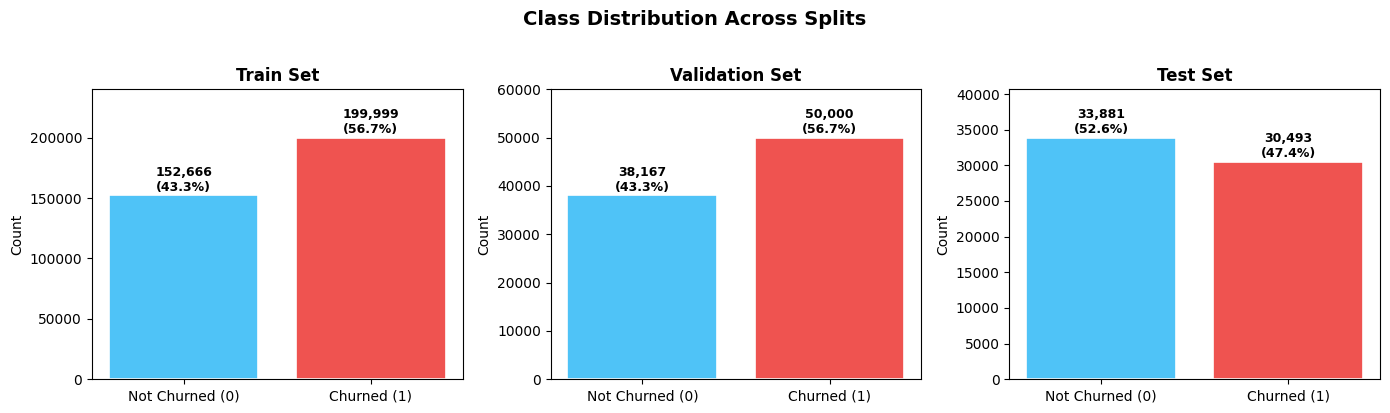

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["#4FC3F7", "#EF5350"]
labels = ["Not Churned (0)", "Churned (1)"]

for ax, (name, y) in zip(axes, [("Train", y_train), ("Validation", y_val), ("Test", y_test)]):
    counts = y.value_counts().sort_index()
    pcts = y.value_counts(normalize=True).sort_index() * 100
    
    bars = ax.bar(labels, counts.values, color=colors, edgecolor="white", linewidth=1.2)
    for i, (cnt, pct) in enumerate(zip(counts.values, pcts.values)):
        ax.text(i, cnt + cnt*0.02, f"{cnt:,}\n({pct:.1f}%)", ha="center", fontweight="bold", fontsize=9)
    ax.set_title(f"{name} Set", fontweight="bold")
    ax.set_ylabel("Count")
    ax.margins(y=0.2)

plt.suptitle("Class Distribution Across Splits", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 8. Tổng Kết

In [15]:
print("=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)
print(f"\n Dataset sizes:")
print(f"   Train:      {X_train_scaled.shape}")
print(f"   Validation: {X_val_scaled.shape}")
print(f"   Test:       {X_test_scaled.shape}")
print(f"\n Features ({len(feature_names)}):")
for i, feat in enumerate(feature_names, 1):
    print(f"   {i:2d}. {feat}")
print(f"\n Target: Churn (binary)")
print(f"   Train Churn ratio:  {y_train.mean():.4f}")
print(f"   Val Churn ratio:    {y_val.mean():.4f}")
print(f"   Test Churn ratio:   {y_test.mean():.4f}")
print(f"\n Missing values: 0")

PREPROCESSING SUMMARY

 Dataset sizes:
   Train:      (352665, 14)
   Validation: (88167, 14)
   Test:       (64374, 14)

 Features (14):
    1. Age
    2. Gender
    3. Tenure
    4. Usage Frequency
    5. Support Calls
    6. Payment Delay
    7. Subscription Type
    8. Contract Length
    9. Total Spend
   10. Last Interaction
   11. Spend_per_Tenure
   12. Usage_per_Tenure
   13. Support_per_Tenure
   14. Delay_x_Support

 Target: Churn (binary)
   Train Churn ratio:  0.5671
   Val Churn ratio:    0.5671
   Test Churn ratio:   0.4737

 Missing values: 0


---

### Ghi chú cho bước tiếp theo (Model Training)

Các biến sẵn sàng để sử dụng:
- `X_train_scaled`, `y_train` → Huấn luyện model
- `X_val_scaled`, `y_val` → Đánh giá & tune hyperparameters
- `X_test_scaled`, `y_test` → Đánh giá cuối cùng
- `feature_names` → Tên các features (cho feature importance)
- `scaler` → Scaler object (cần save để dùng cho inference)